In [ ]:
import numpy as np
import numpy.linalg as la
from scipy.linalg import rq
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly.graph_objects as go

np.set_printoptions(precision = 9, suppress = True)

In [ ]:
# za racunanje cetvrtih temena
def A2H(P):
  x, y = P
  return np.array([x, y, 1], dtype = int)

def H2A(P):
  x1, x2, x3 = P
  if abs(x3) < 1e-11:
    raise ValueError("x3 mora biti razlicito od 0!!!")

  x = x1/x3
  y = x2/x3

  return np.array([x, y])

def prava_kroz_dve_tacke(P, Q):
  return np.cross(P, Q)

def presek_pravih(p, q):
  return np.cross(p, q)

def osmoteme(temena):
  P1, P2, P3, P5, P6, P7, P8 = [A2H(t) for t in temena]

  p67 = prava_kroz_dve_tacke(P6, P7)
  p23 = prava_kroz_dve_tacke(P2, P3)

  P = presek_pravih(p67, p23)
  p1 = prava_kroz_dve_tacke(P1, P)

  p15 = prava_kroz_dve_tacke(P1, P5)
  p26 = prava_kroz_dve_tacke(P2, P6)

  Q = presek_pravih(p15, p26)
  q8 = prava_kroz_dve_tacke(Q, P8)

  P4 = presek_pravih(q8, p1)
  x, y = H2A(P4)
  return (x, y)

In [ ]:
# za racunanje prvog temena

def osmoteme1(temena):
  P2, P3, P4, P5, P6, P7, P8 = [A2H(t) for t in temena]

  p26 = prava_kroz_dve_tacke(P2, P6)
  p37 = prava_kroz_dve_tacke(P3, P7)

  P = presek_pravih(p26, p37)
  p5 = prava_kroz_dve_tacke(P, P5)

  p23 = prava_kroz_dve_tacke(P2, P3)
  p67 = prava_kroz_dve_tacke(P6, P7)

  Q = presek_pravih(p23, p67)
  q4 = prava_kroz_dve_tacke(Q, P4)

  P1 = presek_pravih(q4, p5)
  x, y = H2A(P1)
  return (x, y)

In [ ]:
# temena leve slike

L1 = (385, 1271)
L2 = (606, 1538)
L3 = (1010, 1207)
L5 = (366, 1040)
L6 = (618, 1292)
L7 = (1072, 988)
L8 = (800, 838)
L4 = osmoteme([L1, L2, L3, L5, L6, L7, L8])

L9 = (259, 910)
L10 = (476, 973)
L11 = (563, 862)
L13 = (208, 524)
L14 = (463, 563)
L15 = (566, 496)
L16 = (340, 462)
L12 = osmoteme([L9, L10, L11, L13, L14, L15, L16])

l = [L1, L2, L3, L4, L5, L6, L7, L8, L9, L10, L11, L12, L13, L14, L15, L16]
levo = []

for i in range(len(l)):
  levo.append(A2H(l[i]))

# levo

In [ ]:
D2 = (110, 1340)
D3 = (609, 1474)
D4 = (688, 1204)
D5 = (223, 936)
D6 = (36, 1152)
D7 = (600, 1283)
D8 = (688, 1014)
D1 = osmoteme1([D2, D3, D4, D5, D6, D7, D8])
# print(D1)

D9 = (553, 865)
D10 = (596, 989)
D11 = (788, 956)
D13 = (535, 544)
D14 = (582, 635)
D15 = (810, 608)
D16 = (729, 519)
D12 = osmoteme([D9, D10, D11, D13, D14, D15, D16])
# print(D12)

d = [D1, D2, D3, D4, D5, D6, D7, D8, D9, D10, D11, D12, D13, D14, D15, D16]
desno = []

for i in range(len(d)):
  desno.append(A2H(d[i]))

# desno

In [ ]:
# prebacujemo reper u gornji desni ugao
def piksel(P):
  x, y, z = P
  x = 1200 - x
  return np.array([x, y, z])

In [ ]:
for i in range(len(levo)):
  levo[i] = piksel(levo[i])
  desno[i] = piksel(desno[i])

# print(levo)
# print(desno)

In [ ]:
p1l = (383, 264)
p2l = (727, 351)
p3l = (551, 651)
p4l = (147, 524)
r1l = (1228, 971)
r2l = (1556, 757)
r3l = (1143, 587)
r4l = (1456, 508)
p1r = (489, 183)
p2r = (731, 307)
p3r = (467, 514)
p4r = (214, 347)
r1r = (1050, 994)
r2r = (1491, 903)
r3r = (1127, 630)
r4r = (1343, 589)

# leve8tmp = [p1l, p2l, p3l, p4l, r1l, r2l, r3l, r4l]
# desne8tmp = [p1r, p2r, p3r, p4r, r1r, r2r, r3r, r4r]

# levo = []
# desno = []

# for i in range(8):
  # levo.append(piksel(A2H(leve8tmp[i])))
  # desno.append(piksel(A2H(desne8tmp[i])))

In [ ]:
def vektor9(M1, M2):
  x1, y1, z1 = M1
  x2, y2, z2 = M2

  return np.array([x1*x2, y1*x2, z1*x2,
                   x1*y2, y1*y2, z1*y2,
                   x1*z2, y1*z2, z1*z2])


In [ ]:
def fundamentalna_matrica(leve, desne):
  F = []

  for i in range(len(leve)):
    F.append(vektor9(leve[i], desne[i]))

  return np.array(F)

In [ ]:
# svd dekompozicija

def SVD(A):
    A = np.array(A)
    _, _, Vh = la.svd(A)

    P = Vh[-1].reshape(3, 3)
    P = P / P[2, 2]

    return P

In [ ]:
F = fundamentalna_matrica(levo, desno)
print(F)

[[ 761210 1187114     934  907910 1415894    1114     815    1271       1]
 [ 647460 1676420    1090  795960 2060920    1340     594    1538       1]
 [ 112290  713337     591  280060 1779118    1474     190    1207       1]
 [ 218112  536576     512  512904 1261792    1204     426    1048       1]
 [ 814818 1016080     977  780624  973440     936     834    1040       1]
 [ 677448 1503888    1164  670464 1488384    1152     582    1292       1]
 [  76800  592800     600  164224 1267604    1283     128     988       1]
 [ 204800  429056     512  405600  849732    1014     400     838       1]
 [ 608827  588770     647  813965  787150     865     941     910       1]
 [ 437296  587692     604  716036  962297     989     724     973       1]
 [ 262444  355144     412  608972  824072     956     637     862       1]
 [ 397341  387801     477  698887  682107     839     833     813       1]
 [ 659680  348460     665  539648  285056     544     992     524       1]
 [ 455466  347934     618

In [ ]:
F = SVD(F)
print(F)

[[ 0.000000871 -0.000002893  0.000541232]
 [-0.000003064 -0.000000368 -0.006389759]
 [-0.000778118  0.009701974  1.         ]]


In [ ]:
# matrica kalibracije
K = np.array([
    [1309.15247673,  -10.37233442, 534.22294508],
    [   0.        , 1309.24329365, 747.62606796],
    [   0.        ,    0.        ,   1.        ]
])

In [ ]:
def osnovna_matrica(F, K):
  tmp = F @ K
  return K.T @ tmp

In [ ]:
E = osnovna_matrica(F, K) # radi
print(E)

[[  1.492686051  -4.970044292  -1.513651862]
 [ -5.263755395  -0.548966578 -10.856626614]
 [ -3.408603006  10.346233816   1.013705913]]


In [ ]:
Q0 = np.array([
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])

E0 = np.array([
    [0, 1, 0],
    [-1, 0, 0],
    [0, 0, 0]
])

In [ ]:
U, S, Vt = la.svd(E)
V = Vt.T

print(U)
print(S)
print(V)

[[-0.377781483 -0.229732157 -0.89694163 ]
 [-0.63944741   0.765332244  0.073304617]
 [ 0.669617922  0.601240129 -0.436029983]]
[12.297853743 11.977852555  0.282825482]
[[ 0.04224509  -0.536058412 -0.8431232  ]
 [ 0.744572975  0.579587041 -0.331194725]
 [ 0.666203    -0.613775399  0.423619314]]


In [ ]:
EC = U @ E0 @ U.T
AA = U @ Q0 @ V.T

In [ ]:
print(EC)
print()
print(AA)

[[-0.          -0.436029983 -0.073304617]
 [ 0.436029983 -0.          -0.89694163 ]
 [ 0.073304617  0.89694163   0.         ]]

[[ 0.5440143    0.344967233 -0.76488303 ]
 [-0.372254457  0.916183035  0.1484428  ]
 [ 0.751980758  0.203976111  0.626832263]]


In [ ]:
def koso2v(A):
    return np.array([A[2,1], A[0,2], A[1,0]])

CC = koso2v(EC) # druga kamera
print(CC)

[ 0.89694163  -0.073304617  0.436029983]


In [ ]:
T2 = np.hstack((K, np.zeros((3,1)))) # matrica druge kamere
print(T2)

[[1309.15247673  -10.37233442  534.22294508    0.        ]
 [   0.         1309.24329365  747.62606796    0.        ]
 [   0.            0.            1.            0.        ]]


In [ ]:
R = AA.T
C1 = R @ CC # pozicija prve kamere u drugom reperu
print(C1)
print()
T1 = K @ np.hstack((R, C1.reshape(3,1))) # matrica prve kamere
print(T1)

[ 0.8431232    0.331194725 -0.423619314]

[[ 300.001487741 -417.539251667 1317.209940886  874.034406101]
 [-120.200456087 1310.486201597  735.690495549  116.905631395]
 [  -0.76488303     0.1484428      0.626832263   -0.423619314]]


In [ ]:
# za dobijanje stvarnih koordinata u prostoru
def triang(T1, T2, M1, M2):
    A = np.array([
        M1[1]*T1[2] - M1[2]*T1[1],
       -M1[0]*T1[2] + M1[2]*T1[0],
        M2[1]*T2[2] - M2[2]*T2[1],
       -M2[0]*T2[2] + M2[2]*T2[0]
    ])
    _, _, Vt = la.svd(A)
    M = Vt[-1]
    # print(M)
    return M[:3] / M[3]


In [ ]:
# T1 = np.array([[-2, -1, 0, 2], [-3, 0, 1, 0], [-1, 0, 0, 0]])
# T2 = np.array([[2, -2, 0, -2], [0, -3, 2, -2], [0, -1, 0, 0]])
# M1 = np.array([5, 3, 1])
# M2 = np.array([-2, 1, 1])

# print(triang(T1, T2, M1, M2))

In [ ]:
def rekonstrukcija3D(T1, T2, levo, desno):
  tacke3D = []
  for i in range(len(levo)):
    tacke3D.append(triang(T1, T2, levo[i], desno[i]))


  tacke3D = np.array(tacke3D)
  return tacke3D

In [ ]:
X = rekonstrukcija3D(T1, T2, levo, desno)
print(X)

[[-0.396734014 -0.357727558 -1.29330541 ]
 [-0.462748243 -0.488268172 -1.082084821]
 [-0.046246195 -0.542242585 -0.980193529]
 [ 0.017806276 -0.416903995 -1.203886689]
 [-0.400661812 -0.166414651 -1.182659015]
 [-0.467126658 -0.297124325 -0.967130861]
 [-0.045655598 -0.350239976 -0.858809083]
 [ 0.01728633  -0.216894101 -1.083407317]
 [-0.141857545 -0.13718056  -1.648725037]
 [-0.0782505   -0.261349591 -1.445787352]
 [ 0.138181726 -0.230927532 -1.489980581]
 [ 0.074475265 -0.107670481 -1.697856345]
 [-0.143240663  0.231644111 -1.452236187]
 [-0.078139818  0.111289367 -1.237427218]
 [ 0.142603851  0.141649642 -1.283267523]
 [ 0.074231381  0.266030617 -1.494335793]]


In [ ]:
edges_cube1 = [
    (0,1), (1,2), (2,3), (3,0),
    (4,5), (5,6), (6,7), (7,4),
    (0,4), (1,5), (2,6), (3,7)
]

edges_cube2 = [
    (8,9), (9,10), (10,11), (11,8),
    (12,13), (13,14), (14,15), (15,12),
    (8,12), (9,13), (10,14), (11,15)
]


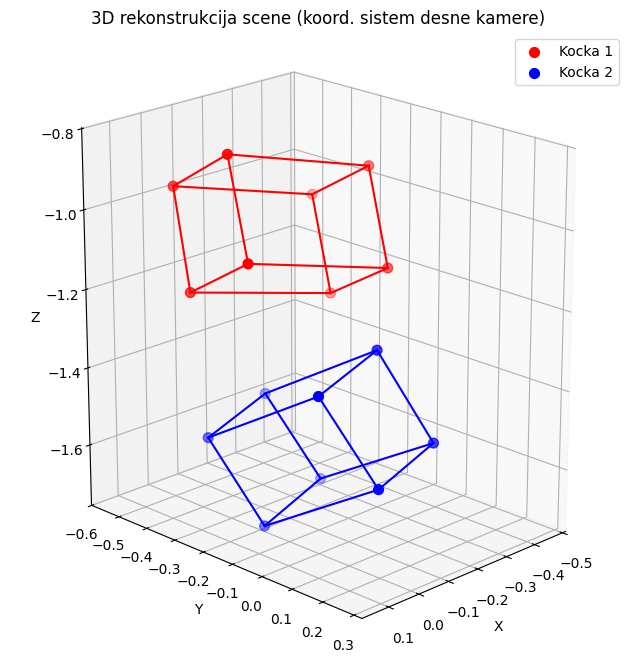

In [ ]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(111, projection = '3d')

# tacke
ax.scatter(X[:8,0],  X[:8,1],  X[:8,2],  c = 'red',  s = 50, label = 'Kocka 1')
ax.scatter(X[8:,0],  X[8:,1],  X[8:,2],  c = 'blue', s = 50, label = 'Kocka 2')

# ivice
for i, j in edges_cube1:
    ax.plot([X[i, 0], X[j, 0]],
            [X[i, 1], X[j, 1]],
            [X[i, 2], X[j, 2]], 'r')

for i, j in edges_cube2:
    ax.plot([X[i, 0], X[j, 0]],
            [X[i, 1], X[j, 1]],
            [X[i, 2], X[j, 2]], 'b')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_title("3D rekonstrukcija scene (koord. sistem desne kamere)")
ax.legend()
ax.view_init(elev = 20, azim = 45)

ax.set_box_aspect([
    np.ptp(X[:, 0]),
    np.ptp(X[:, 1]),
    np.ptp(X[:, 2])
])

plt.show()


In [ ]:
fig = go.Figure()

# tacke
fig.add_trace(go.Scatter3d(
    x = X[:8, 0], y = X[:8, 1], z = X[:8, 2],
    mode = 'markers',
    marker = dict(size = 5, color = 'red'),
    name = 'Kocka 1'
))

fig.add_trace(go.Scatter3d(
    x = X[8:, 0], y = X[8:, 1], z = X[8:, 2],
    mode = 'markers',
    marker = dict(size = 5, color = 'blue'),
    name = 'Kocka 2'
))

# ivice
def add_edges(edges, color):
    for i, j in edges:
        fig.add_trace(go.Scatter3d(
            x = [X[i, 0], X[j, 0]],
            y = [X[i, 1], X[j, 1]],
            z = [X[i, 2], X[j, 2]],
            mode = 'lines',
            line = dict(color = color, width = 3),
            showlegend = False
        ))

add_edges(edges_cube1, 'red')
add_edges(edges_cube2, 'blue')

fig.update_layout(
    title = "3D rekonstrukcija scene (koord. sistem desne kamere)",
    scene = dict(
        xaxis_title = 'X',
        yaxis_title = 'Y',
        zaxis_title = 'Z'
    ),
    width = 800,
    height = 800
)

fig.show()
